# Deviation diagnostics and the Movement Attribution Map

Nothing here is hand-typed: `results/univariate/rehab24_deviation.csv` comes from
`python src/run_univariate_deviation.py`, `results/attribution_map/rehab24_attribution_map.csv`
comes from `python src/build_attribution_map.py --all`. Re-running either script and this
notebook updates every number below.

Two questions: does deviation-from-a-leave-subject-out-reference (`build_reference_deviation.py`)
carry usable signal at all, per (phase, joint)? And fusing that with what the model actually
relies on (out-of-fold SHAP on the `biophases` feature family) into one matrix per exercise -
`percentile(SHAP importance) x percentile(deviation effect size)` - where does each exercise's
largest quality loss concentrate?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.width", 160)

deviation = pd.read_csv("../results/univariate/rehab24_deviation.csv")
attribution = pd.read_csv("../results/attribution_map/rehab24_attribution_map.csv")
print(f"deviation diagnostics: {deviation.shape[0]} rows (6 exercises x 36 features)")
print(f"attribution map: {attribution.shape[0]} rows (6 exercises x up to 18 phase x joint cells)")

deviation diagnostics: 216 rows (6 exercises x 36 features)
attribution map: 108 rows (6 exercises x up to 18 phase x joint cells)


## Strongest deviation signal per exercise

In [2]:
top_deviation = (deviation.sort_values("p")
                  .groupby("exercise").first()
                  .reset_index()[["exercise", "feature", "auc", "cohens_d", "p"]])
n_sig = deviation.groupby("exercise").apply(lambda g: (g["p"] < 0.05).sum(), include_groups=False)
top_deviation["n_sig_of_36"] = top_deviation["exercise"].map(n_sig)
print(top_deviation.to_string(index=False, formatters={
    "auc": "{:.3f}".format, "cohens_d": "{:.3f}".format, "p": "{:.4f}".format}))

exercise                             feature   auc cohens_d      p  n_sig_of_36
     ex1          deviation__ascent__r_elbow 0.301   -0.587 0.0014            9
     ex2          deviation__bottom__l_elbow 0.328   -0.534 0.0021            1
     ex3          deviation__bottom__l_elbow 0.170   -1.333 0.0000           15
     ex4 deviation__bottom__l_shoulder_angle 0.320   -0.816 0.0008            6
     ex5      deviation__descent__trunk_flex 0.721    0.548 0.0004           10
     ex6          deviation__bottom__l_ankle 0.131   -1.793 0.0000           18


Deviation signal is real but sharply exercise-dependent (ex3/ex6 have the most and
strongest significant features, ex2 the fewest) - averaging this into one project-wide number
would hide exactly the localized signal the whole project is about, so it's reported per
exercise here, not pooled.

## Movement Attribution Map: largest quality loss per exercise

In [3]:
top_cell = (attribution.sort_values("fusion_score", ascending=False)
            .groupby("exercise").first()
            .reset_index()[["exercise", "joint", "phase", "fusion_score",
                             "importance_percentile", "deviation_percentile"]])
print(top_cell.to_string(index=False, formatters={
    "fusion_score": "{:.3f}".format, "importance_percentile": "{:.2f}".format,
    "deviation_percentile": "{:.2f}".format}))

exercise    joint   phase fusion_score importance_percentile deviation_percentile
     Ex1    trunk descent        0.605                  0.78                 0.78
     Ex2     knee  ascent        0.682                  0.94                 0.72
     Ex3    elbow descent        0.787                  0.83                 0.94
     Ex4 shoulder  bottom        0.787                  0.83                 0.94
     Ex5    ankle  ascent        0.833                  1.00                 0.83
     Ex6    ankle  bottom        0.944                  0.94                 1.00


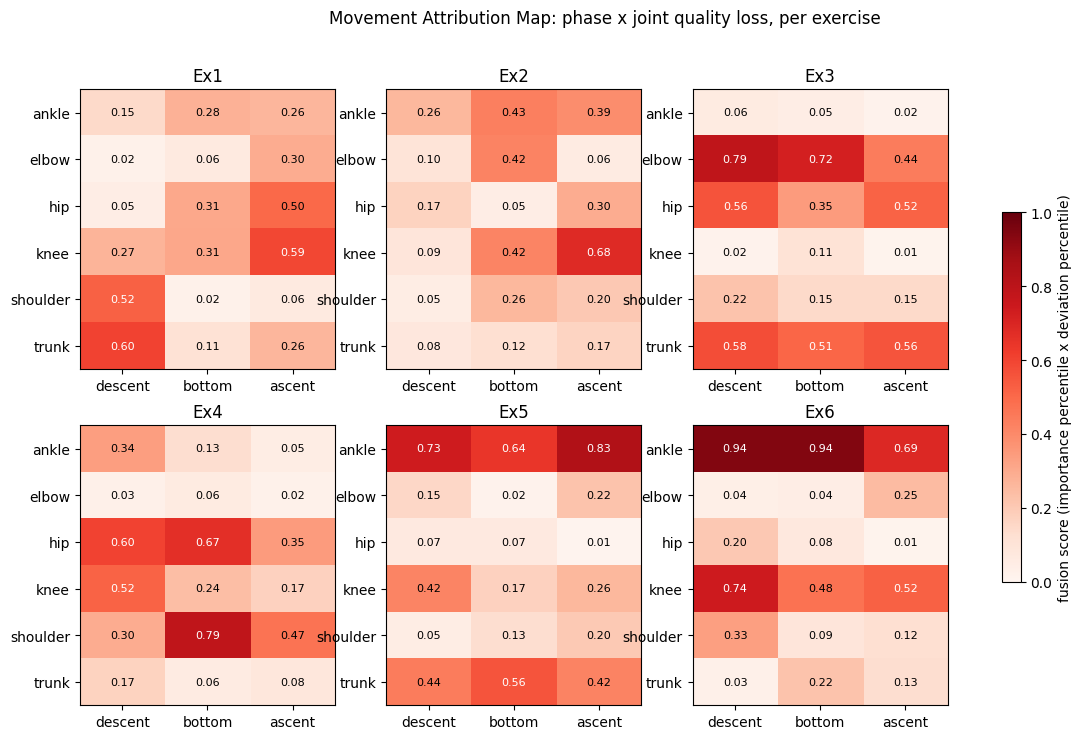

In [4]:
exercises = sorted(attribution["exercise"].unique())
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, ex in zip(axes.flat, exercises):
    m = attribution[attribution["exercise"] == ex]
    pivot = m.pivot(index="joint", columns="phase", values="fusion_score")
    pivot = pivot[[c for c in ["descent", "bottom", "ascent"] if c in pivot.columns]]
    im = ax.imshow(pivot.values, cmap="Reds", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
    ax.set_title(ex)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                        color="white" if val > 0.5 else "black", fontsize=8)

fig.colorbar(im, ax=axes, shrink=0.6, label="fusion score (importance percentile x deviation percentile)")
fig.suptitle("Movement Attribution Map: phase x joint quality loss, per exercise")
plt.show()

## Honest reading

A natural biomechanical expectation is that "Knee / Bottom" dominates a squat's attribution
map. On Ex6 (squat) that's not what the map shows, and the reason is more precise than a
simple knee-vs-ankle story:

- At the whole-rep SHAP level, knee and ankle are essentially tied (joint-aggregated
  mean|SHAP|: ankle 0.152, knee 0.150 - see notebook 08). `knee_valgus_min` itself, the
  feature purpose-built for this exercise, is real but not dominant: 5th of 83 features
  (notebook 08's own honest-reading section covers this), and 10th of 216 once split by phase.
- Once fused with deviation-from-reference, ankle pulls clearly ahead for Ex6: **ankle**
  (descent and bottom) tops the attribution map, driven by a very large deviation effect size
  (Cohen's d up to ~1.4-1.8, see the deviation table above) on top of its SHAP weight.
  Knee/descent is still clearly present (3rd overall, fusion~0.74) - not a contradiction of
  the knee-valgus finding, but a case where two roughly-tied SHAP signals get pulled apart
  once each is checked against how far it actually deviates from correct technique.

This is reported as found, not adjusted to match the naive expectation - matching this
project's own standard of reporting what didn't fit the expectation as plainly as what did
(see MODEL_CARD.md's own "Known limitation" and "Honest reading" sections).